# **Impact of Macroeconomic Factors on The Life Expectancy in Developed and Developing Nations**

#Objective:

To determine and rank the isolated effects of economic and health factors that influence the life expectancy of citizens in developed and developing nations, using World Health Organization Data, to guide strategic resource allocation and maximize the return on social investments.

#Key Findings:

**Developing Nations:**

Within these nations the 3 largest key factors affecting Life Expectancy were: HIV/Aids, Adult Mortality, and Schooling.

Lifespan here is strictly capped by systemic health crises and baseline infrastructure.

Social capital must prioritize infectious disease conatinment and primary education.

**Developed Nations:**

Within these nations the 3 largest key factors affecting Life Expectancy were: Income Composition, Alcohol, and Thinness.

Once basic survival is met, raw GDP loses its impact. Longevity becomes dictate by wealth distribution and behavioural health trends.

Social capital should focus on substance abuse education/intervention and equitable resource allocation.

#Methodology:

Conventional predictive machine learning frequently produces biased artificially confident results while ignoring real-world economics. I created a unique mathematically demanding econometric pipeline to compute these particular results.

Neutralized Multicollinearity: VIF scoring was used to find and remove zero-variance flatlines and redundant variables .

Smart Model Optimization: Developed a unique Backward Elimination algorithm that removes statistical noise while specifically preventing the algorithm from erasing important macroeconomic drivers.

Standardized Insights: Standardized the inputs using their Z-scores to produce a definitive mathematically objective leaderboard.


# **Environment Initilaization and Loading Data**

# Goal:
 Understand the values within the World Health Organization Life Exoectancy date and check it's structural integrity

# Task:
In order to complete a regression analysis for inference on the dataset, later on, several libraries are imported into the environment.

Next the raw data set is read into the environment and it's dimensions are checked in order to determine the size of the dataset

Finally check the feature schema to establish a baseline before commencing the data cleaning phase.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from scipy.stats import zscore

df = pd.read_csv('led.csv')
print(df.shape)
df.head(20)

(2938, 22)


,Country,Year,Status,Lifeexpectancy,AdultMortality,infantdeaths,Alcohol,percentageexpenditure,HepatitisB,Measles,...,Polio,Totalexpenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness1-19years,thinness5-9years,Incomecompositionofresources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
5,Afghanistan,2010,Developing,58.8,279.0,74,0.01,79.679367,66.0,1989,...,66.0,9.20,66.0,0.1,553.328940,2883167.0,18.4,18.4,0.448,9.2
6,Afghanistan,2009,Developing,58.6,281.0,77,0.01,56.762217,63.0,2861,...,63.0,9.42,63.0,0.1,445.893298,284331.0,18.6,18.7,0.434,8.9
7,Afghanistan,2008,Developing,58.1,287.0,80,0.03,25.873925,64.0,1599,...,64.0,8.33,64.0,0.1,373.361116,2729431.0,18.8,18.9,0.433,8.7
8,Afghanistan,2007,Developing,57.5,295.0,82,0.02,10.910156,63.0,1141,...,63.0,6.73,63.0,0.1,369.835796,26616792.0,19.0,19.1,0.415,8.4
9,Afghanistan,2006,Developing,57.3,295.0,84,0.03,17.171518,64.0,1990,...,58.0,7.43,58.0,0.1,272.563770,2589345.0,19.2,19.3,0.405,8.1


# **Missing Data Check** #

#Goal:
Determine Actions for Missing Values

#Task:
Check which columns/variables have missing data, and determine what action should be taken to correct missing data.

In [ ]:
#Check which categories have null values and how many
missing_data = df.isnull().sum()

print('Missing Values For Variables')
#Print how null values for each column
print(missing_data.sort_values())

Missing Values For Variables
Country                           0
Year                              0
Status                            0
infantdeaths                      0
percentageexpenditure             0
HIV/AIDS                          0
under-fivedeaths                  0
Measles                           0
Lifeexpectancy                   10
AdultMortality                   10
Diphtheria                       19
Polio                            19
BMI                              34
thinness5-9years                 34
thinness1-19years                34
Schooling                       163
Incomecompositionofresources    167
Alcohol                         194
Totalexpenditure                226
GDP                             448
HepatitisB                      553
Population                      652
dtype: int64


# **Dealing With Missing Values**

# Goal:
Resolve the missing data issues by following a systematic process that aims to provide realistics values for missing data values.

#Task:
Firstly any observation without a value for Life Expectancy will immediately be deleted as we cannot create an estimate for it's values, as it is the Y variable and we cannot build a model off of predicted Y values.

Then remove the population column from the data set as a substantial amount (22%) of population values are missing.

Finally for any other missing values, the median of all other values for the same "Country" will be used to fill in this missing data. However if all values for one variable is missing for a specific "Country" then then value will be predicted with the median of the values of the same "Status"











In [ ]:
#Drop all rows where 'Life Expectancy' is null
df = df.dropna(subset='Lifeexpectancy')

#Drop the 'Population' column
df = df.drop(columns=['Population'])

#Check which columns have missing data values and add them to a list
null_columns = df.columns[df.isnull().any()].tolist()

#Run through the columns with missing values and insert appropriate medians
for col in null_columns:
    df[col] = df[col].fillna(df.groupby('Country')[col].transform('median'))
    df[col] = df[col].fillna(df.groupby('Status')[col].transform('median'))

#Check if there are any null values remaining in the adjusted data set
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2928 entries, 0 to 2937
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country                       2928 non-null   object 
 1   Year                          2928 non-null   int64  
 2   Status                        2928 non-null   object 
 3   Lifeexpectancy                2928 non-null   float64
 4   AdultMortality                2928 non-null   float64
 5   infantdeaths                  2928 non-null   int64  
 6   Alcohol                       2928 non-null   float64
 7   percentageexpenditure         2928 non-null   float64
 8   HepatitisB                    2928 non-null   float64
 9   Measles                       2928 non-null   int64  
 10  BMI                           2928 non-null   float64
 11  under-fivedeaths              2928 non-null   int64  
 12  Polio                         2928 non-null   float64
 13  Totalexp

# **Duplicates and Outlier**

Check data for duplicates and illogical outliers

In [ ]:
#Check for the number of duplicates in the dataset
print(f"Check for duplicate rows: {df.duplicated().sum()}")

#Quick check for any extreme outliers in the data
print(f"Quick check for extreme outliers: {df.describe()}")

Check for duplicate rows: 0
Quick check for extreme outliers:              Year  Lifeexpectancy  AdultMortality  infantdeaths      Alcohol  \
count  2928.00000     2928.000000     2928.000000   2928.000000  2928.000000   
mean   2007.50000       69.224932      164.796448     30.407445     4.610236   
std       4.61056        9.523867      124.292079    118.114450     4.035810   
min    2000.00000       36.300000        1.000000      0.000000     0.010000   
25%    2003.75000       63.100000       74.000000      0.000000     0.950000   
50%    2007.50000       72.100000      144.000000      3.000000     3.735000   
75%    2011.25000       75.700000      228.000000     22.000000     7.685000   
max    2015.00000       89.000000      723.000000   1800.000000    17.870000   

       percentageexpenditure   HepatitisB        Measles          BMI  \
count            2928.000000  2928.000000    2928.000000  2928.000000   
mean              740.321185    80.277322    2427.855874    38.201673  

# **Create Heat Maps for Developed and Developing Nations**

#Goal:
Create a heat map to visualize the correlation between the different macroeconomic factors in the data set.

#Task:
The data is split between developing and developed nations in order to determine which variables affect Life Expectancy the most for the different nation Status'.

This is done as it isn't expected that the same factors affect the two status' equally.

The heat map helps give an indcation on which variables are affecting Life Expectancy the most and which variables could pose a multicollinearity problem.

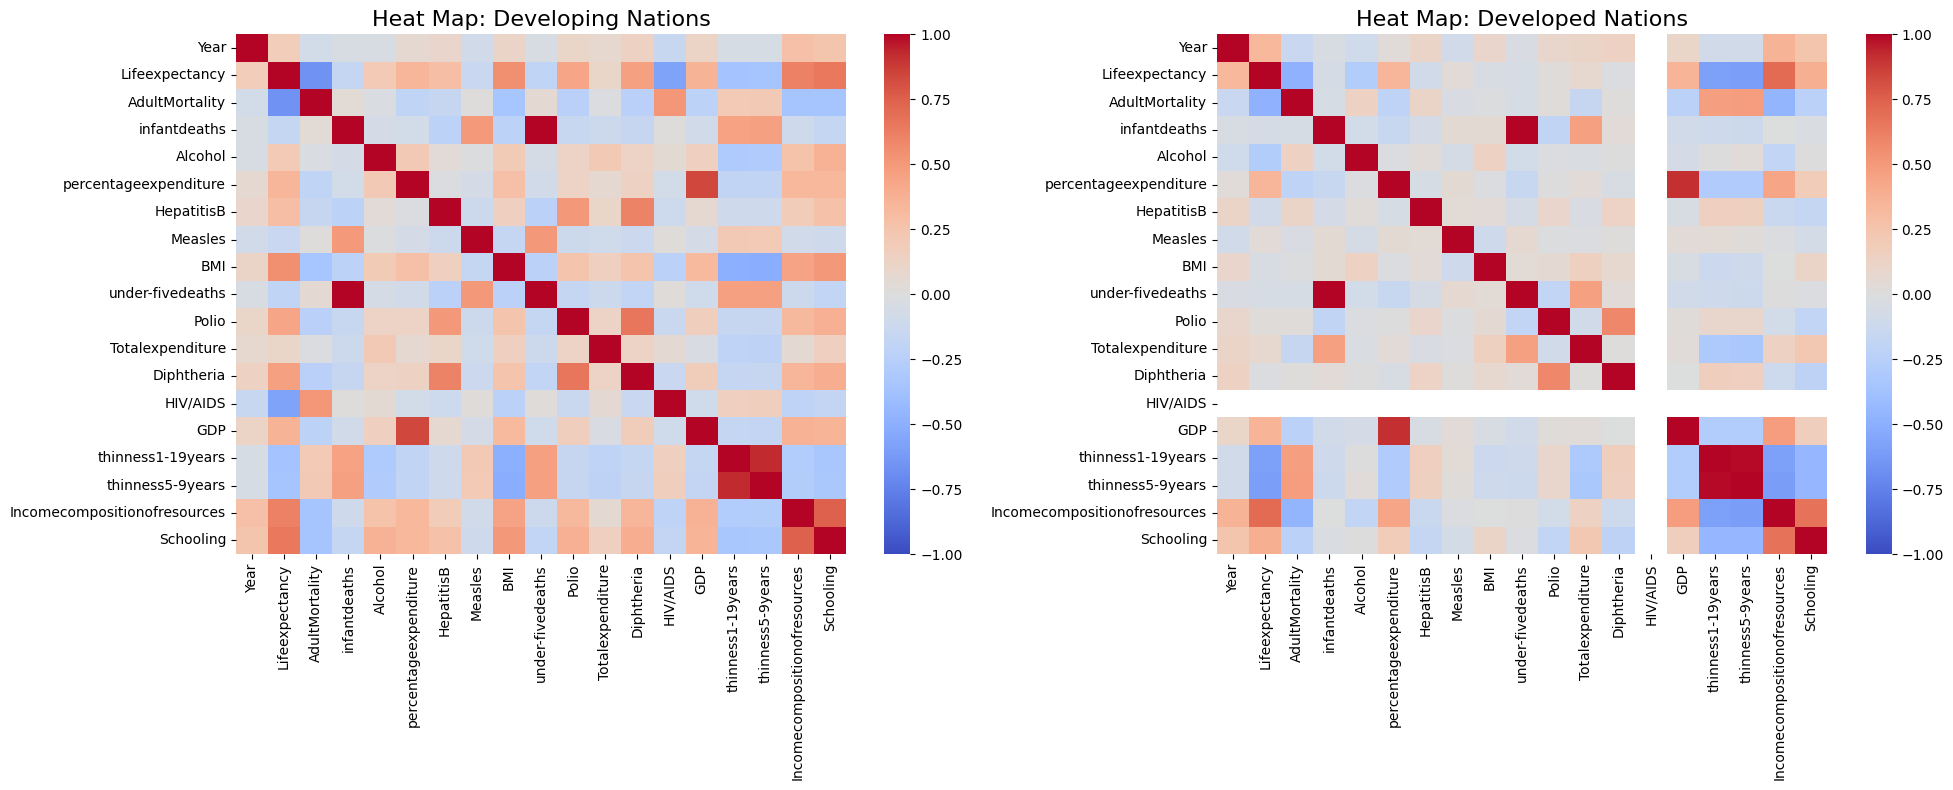

In [ ]:
#Split the data into "Developed" and "Developing" sections
developing = df[df['Status'] == 'Developing']
developed = df[df['Status'] == 'Developed']

#Create a list of all columns with numeric data types
number_columns = df.select_dtypes(include=['float64', 'int64']).columns

plt.figure(figsize=(20, 8))

#Create a heat map for developing nations
plt.subplot(1, 2, 1)
corr_developing = developing[number_columns].corr()
sns.heatmap(corr_developing, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Heat Map: Developing Nations', fontsize=16)

#Create a heat map for developed nations
plt.subplot(1, 2, 2)
corr_developed = developed[number_columns].corr()
sns.heatmap(corr_developed, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Heat Map: Developed Nations', fontsize=16)

# Display both heat maps
plt.tight_layout()
plt.show()

# **VIF Scores**

# Goal:
Determine the level of multicollinearity for each variable to determine which ones should be eliminated to ensure a a regression model that produces the best results.

# Task:
Calculate the VIF scores for all the numeric variables for Developing and Developed nations in order to determine which variables to be included in the multi-linear regression model.

We calculate these values because if two variables measure the exact same economic reality thay act as duplicates and confuse the regression model alogrithm.

With the VIF score we can see which variables we are most likely to eliminate as we have an indication of how much they are already represented by the other variables.

In [ ]:
#Create function to determine VIF scores for explanatory variables
def VIF_scores (status_df, columns):

  #Get rid of Y variable ie. 'Life Expectancy'
  X_data = status_df[columns].drop(columns=['Lifeexpectancy'])

  #Add a constant to X variables
  X_with_const = add_constant(X_data)

  #Create a new empty dataframe
  vif_data = pd.DataFrame()

  #Assign all variable names to variable column
  vif_data["Variable"] = X_with_const.columns

  #Calculate VIF scores for all variables
  vif_data["VIF_Score"] = [variance_inflation_factor(X_with_const.values, i)
                          for i in range(X_with_const.shape[1])]

  #Get rid of constant variable VIF score as it acted as intercept which does
  #not have multicollinearity
  vif_data = vif_data[vif_data['Variable'] != 'const']

  #Return the VIF scores in descending order
  return vif_data.sort_values(by='VIF_Score', ascending=False).reset_index(drop=True)

#Determine VIF scores for Developing Nations
print('VIF Score: Developing Nations')
print(VIF_scores(developing, number_columns))

#Determine VIF Scores for Developed Nations
print('VIF Score: Developed Nations')
print(VIF_scores(developed, number_columns ))

VIF Score: Developing Nations
                        Variable   VIF_Score
0               under-fivedeaths  172.819534
1                   infantdeaths  171.075970
2               thinness5-9years    7.658890
3              thinness1-19years    7.534352
4                            GDP    3.846284
5          percentageexpenditure    3.745360
6                      Schooling    2.863178
7   Incomecompositionofresources    2.487861
8                     Diphtheria    2.329107
9                          Polio    1.914796
10                           BMI    1.783180
11                    HepatitisB    1.746949
12                AdultMortality    1.615632
13                      HIV/AIDS    1.434157
14                       Measles    1.378949
15                       Alcohol    1.367377
16              Totalexpenditure    1.163619
17                          Year    1.157606
VIF Score: Developed Nations
                        Variable      VIF_Score
0                       HIV/AIDS  2468

# **Remove Variables With High VIF Scores**

#Goal:
Remove all highly correlated variables to ensure a a mathematically sound, set of variables.

#Task:
Manually identify variables with high VIF scores that are highly correlated with other variables and determine the best variables to remove.

Update the column lists and re-run the VIF function to check that the remaining vairables now have decent VIF values.

This is in an effort to reduce multicollinearity in the model.

In [ ]:
#Remove variables with high VIF scores that were clearly correlated to other variables
developing = developing.drop(columns=['under-fivedeaths','thinness5-9years'])
developed = developed.drop(columns=['HIV/AIDS','under-fivedeaths','thinness5-9years'])

In [ ]:
#Identify all column names for numerical data to ensure VIF can be calculated
developing_columns = developing.select_dtypes(include=['float64','int64']).columns
developed_columns = developed.select_dtypes(include=['float64','int64']).columns

#Print new VIF scores for remaining variables
print('VIF Score: Developing Nations')
print(VIF_scores(developing, developing_columns))

print('VIF Score: Developed Nations')
print(VIF_scores(developed, developed_columns ))

VIF Score: Developing Nations
                        Variable  VIF_Score
0                            GDP   3.842240
1          percentageexpenditure   3.745316
2                      Schooling   2.847683
3   Incomecompositionofresources   2.468765
4                     Diphtheria   2.289806
5                          Polio   1.906455
6              thinness1-19years   1.790661
7                            BMI   1.749627
8                     HepatitisB   1.741067
9                   infantdeaths   1.701908
10                AdultMortality   1.611423
11                      HIV/AIDS   1.429683
12                       Measles   1.363605
13                       Alcohol   1.334939
14              Totalexpenditure   1.159841
15                          Year   1.156382
VIF Score: Developed Nations
                        Variable  VIF_Score
0                            GDP   6.507385
1          percentageexpenditure   6.317438
2   Incomecompositionofresources   3.849788
3                

# **Create Best Model With Backward Elimination**

#Goal:
Remove unneccessary variables from the regression model in order to create a parsimomious model that removes as much statistical noise as possible, whilst mataining core economic drivers.

#Task
Create a standard backward elimination algorithm that looks at the p-values of variables and systematically removes variables from the model that have a p-value>0.05 and are not considered statistically significant.

An adjustment however was made to protect variables that may have high p-values but in reality are integral to Life Expectancy value, these variables were removed from any elimination process.

The Year column was also removed as it is not neccessarily a variable that affects Life Expectancy however would have most likely demonstrate an effect in the model due to the fact that over time it is expected that countries develop.

The best model would display similar predictive power (R-squared) as the intitial model whilst removing unnecessary variables. This would help reduce fitting bias from the model.



In [ ]:
def smart_backward_elimination(dataset, target, protected_vars=[], significance_level=0.05):

    #Creates a dataset to store Life Expectancy as the Y variable
    y = dataset[target]

    #Choose to drop Life Expectancy as it is the variable we are trying to predict
    #We drop the status and country as it is irrelevant to the datasets
    #Year is dropped as it we expect countries to develop over time and it will
    #add complexity to the model which should not be there.
    columns_to_drop = [target, 'Country', 'Status', 'Year']

    #Create the X dataset and drop the variables previously specified.
    X = dataset.drop(columns=columns_to_drop, errors='ignore')

    #Add a constant to the model as an intercept is required for statsmodel to function correctly
    X = sm.add_constant(X)

    #Checks whether the protected_vars list is true/has anything in it and if it does it prints it
    #if len(protected_vars) > 0:
    if protected_vars:
        print(f"Protected Variables: {protected_vars}")

    while True:
        #Fit the model
        model = sm.OLS(y, X).fit()

        #Get the p-values of variables, but hide the constant and protected variables
        #to prevent them from getting removed from the model due to low p-values
        p_values_to_check = model.pvalues.drop(['const'] + protected_vars, errors='ignore')

        #Stops the while loop when there are no longer any p-values to check
        if len(p_values_to_check) == 0:
            break

        #Find the p-value of the worst performing variable
        max_p_value = p_values_to_check.max()

        #Provides the name associated to the worst/largets p-value
        worst_feature = p_values_to_check.idxmax()

        #Eliminate any non protected variable if it fails the 0.05 statistical significance test
        if max_p_value > significance_level:
            print(f"Dropping '{worst_feature}' (P-value: {max_p_value:.4f})")
            X = X.drop(columns=[worst_feature])
        else:
            print("--- Optimal Model Reached! ---")
            break

    #Return the final, cleaned-up model
    return sm.OLS(y, X).fit()

#State protected variables for developed and developing models
developed_protected = ['GDP', 'Incomecompositionofresources', 'Schooling']
developing_protected = ['GDP', 'HIV/AIDS', 'Schooling']

#Determine the best Developed Nation Model
print("Best Developed Nation Model")
best_developed_model = smart_backward_elimination(developed, 'Lifeexpectancy', protected_vars=developed_protected)
print(best_developed_model.summary())

#Determine the best Developing Nation Model
print("Best Developing Nation Model")
best_developing_model = smart_backward_elimination(developing, 'Lifeexpectancy', protected_vars=developing_protected)
print(best_developing_model.summary())



Best Developed Nation Model
Protected Variables: ['GDP', 'Incomecompositionofresources', 'Schooling']
Dropping 'Polio' (P-value: 0.7792)
Dropping 'HepatitisB' (P-value: 0.5653)
Dropping 'Measles' (P-value: 0.2050)
Dropping 'BMI' (P-value: 0.1372)
--- Optimal Model Reached! ---
                            OLS Regression Results                            
Dep. Variable:         Lifeexpectancy   R-squared:                       0.618
Model:                            OLS   Adj. R-squared:                  0.610
Method:                 Least Squares   F-statistic:                     80.91
Date:                Tue, 28 Apr 2026   Prob (F-statistic):           6.63e-98
Time:                        16:44:18   Log-Likelihood:                -1180.8
No. Observations:                 512   AIC:                             2384.
Df Residuals:                     501   BIC:                             2430.
Df Model:                          10                                         
Covariance 

# **Confirm Assumptions Are Met**

#Goal
Prove that the final regression models do not violate the OLS assumptions and that the coefficients are not biased.

#Task:
Plot the residuals against the fitted line in order to confirm that the models were homoscedastic and linear.

Plot a histogram to check that residuals are normally distributed and therefore random.

Use a QQ Plot as another check for normality in the distribution of the residuals

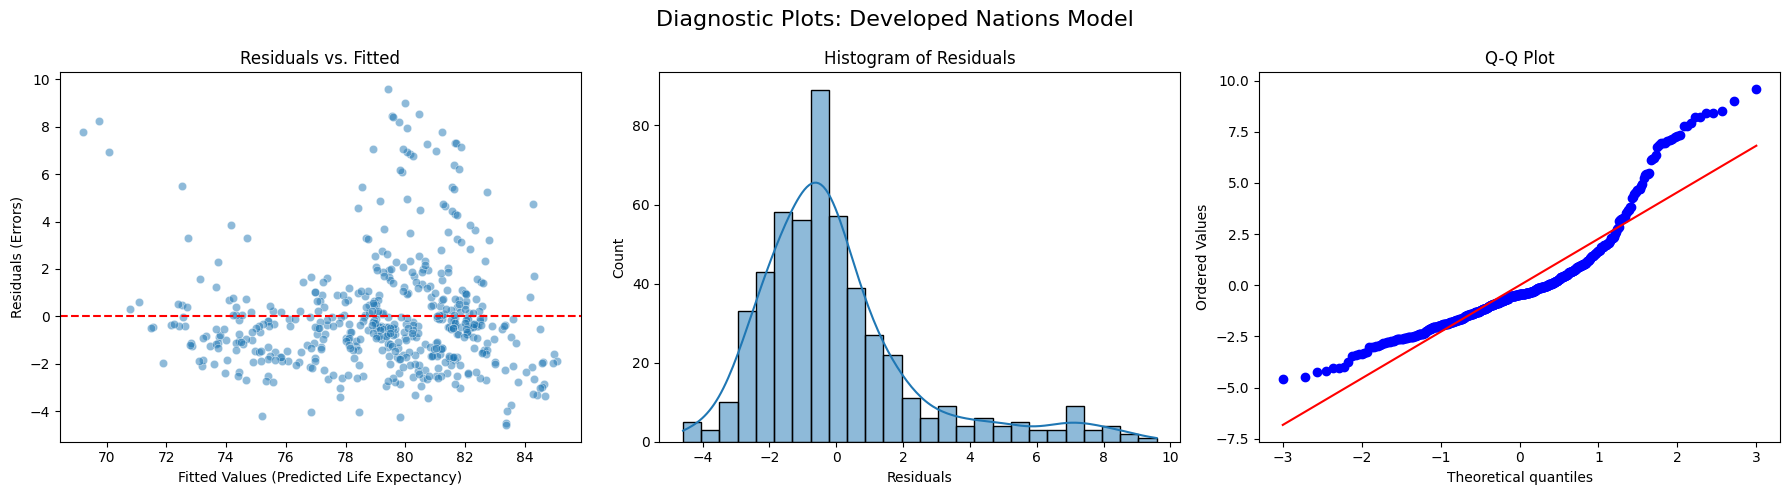

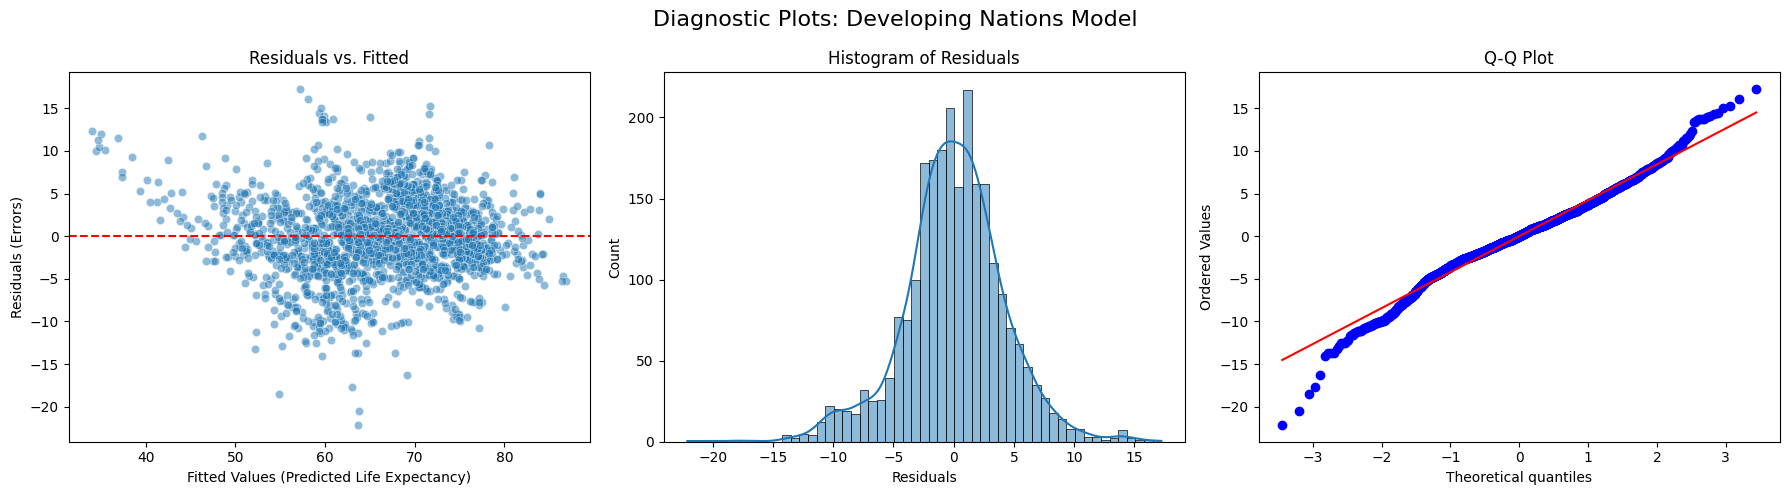

In [ ]:
def check_ols_assumptions(model, title):
    # Get the fitted values and the residuals from your model
    fitted_vals = model.fittedvalues
    residuals = model.resid

    # Set up a 1x3 grid for our plots
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Diagnostic Plots: {title}', fontsize=16)

    #Residuals vs Fitted (Checks Linearity and Homoscedasticity)
    sns.scatterplot(x=fitted_vals, y=residuals, ax=axes[0], alpha=0.5)
    axes[0].axhline(0, color='red', linestyle='--')
    axes[0].set_xlabel('Fitted Values (Predicted Life Expectancy)')
    axes[0].set_ylabel('Residuals (Errors)')
    axes[0].set_title('Residuals vs. Fitted')

    #Histogram of Residuals (Checks Normality)
    sns.histplot(residuals, kde=True, ax=axes[1])
    axes[1].set_xlabel('Residuals')
    axes[1].set_title('Histogram of Residuals')

    #QQ Plot (Strict check for Normality)
    stats.probplot(residuals, dist="norm", plot=axes[2])
    axes[2].set_title('Q-Q Plot')

    plt.tight_layout()
    plt.show()

# Run the auditor on your completed models!
check_ols_assumptions(best_developed_model, "Developed Nations Model")
check_ols_assumptions(best_developing_model, "Developing Nations Model")

# **Determine Most Important Variable**

A function is created to standardize the effects of variables in the model.
The highest calculated coefficient for the s standardized values will be considered as the most valuable variables to the model


In [ ]:
def get_variable_importance(model):
    #Extract the raw numbers and column names straight from the engine
    X_data = pd.DataFrame(model.model.exog, columns=model.model.exog_names)

    #Drop the constant so it doesn't mess up the scaling
    X_no_const = X_data.drop(columns=['const'], errors='ignore')

    #Convert all variables into Z-scores (Standard Deviations)
    X_scaled = X_no_const.apply(zscore)

    # Add the constant back
    X_scaled = sm.add_constant(X_scaled)

    #Re-run the regression using the scaled data
    scaled_model = sm.OLS(model.model.endog, X_scaled).fit()

    #Extract the coefficients, take the absolute value, and sort them
    importance = pd.DataFrame({
        'Variable': X_no_const.columns,
        'Standardized_Impact': np.abs(scaled_model.params.drop('const').values)
    })

    # Sort from most powerful to least powerful
    return importance.sort_values(by='Standardized_Impact', ascending=False).reset_index(drop=True)

# Run it cleanly with just the model!
print("--- Variable Importance Ranking (Developing Nations) ---")
print(get_variable_importance(best_developing_model))

print("--- Variable Importance Ranking (Developed Nations) ---")
print(get_variable_importance(best_developed_model))

--- Variable Importance Ranking (Developing Nations) ---
                        Variable  Standardized_Impact
0                       HIV/AIDS             2.719722
1                 AdultMortality             2.438152
2                      Schooling             2.116227
3                            BMI             1.225916
4                     Diphtheria             1.044642
5   Incomecompositionofresources             1.017120
6          percentageexpenditure             0.804236
7                          Polio             0.745688
8                        Measles             0.406599
9                        Alcohol             0.264521
10                           GDP             0.152159
--- Variable Importance Ranking (Developed Nations) ---
                       Variable  Standardized_Impact
0  Incomecompositionofresources             2.125254
1             thinness1-19years             1.213507
2                       Alcohol             0.698276
3         percentageexpendi

# **Graphically Display The Most Important Variables**

Create bar charts that display and rank variables based on their importance.

/tmp/ipykernel_1462/1257120767.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


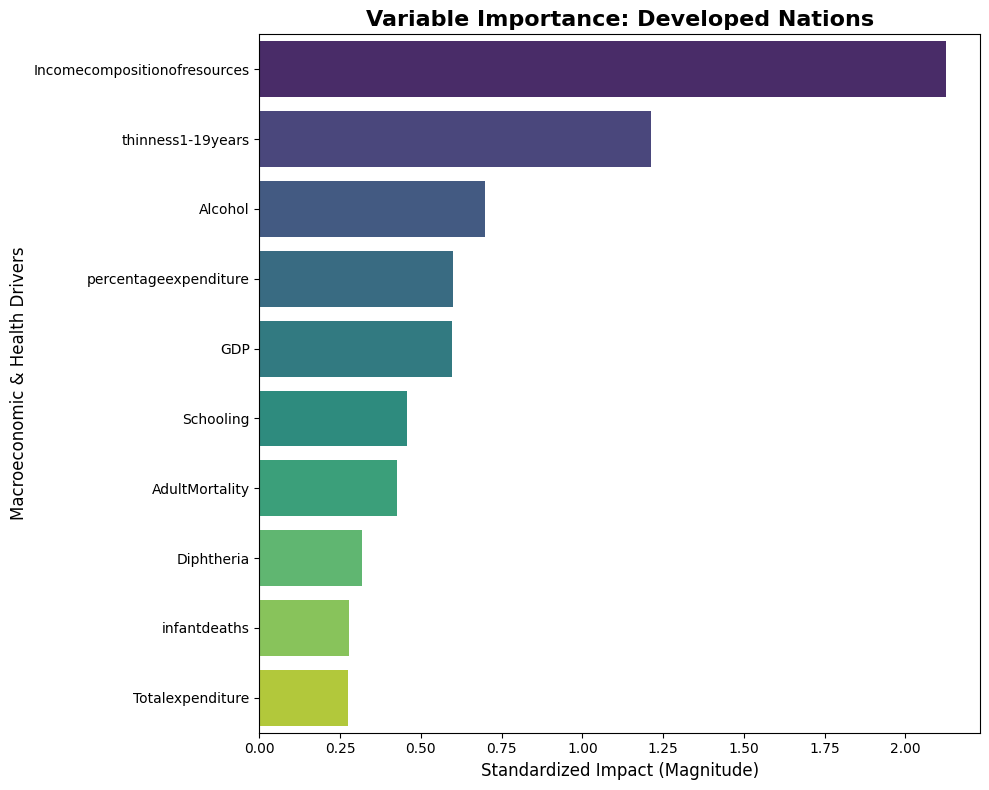

/tmp/ipykernel_1462/1257120767.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


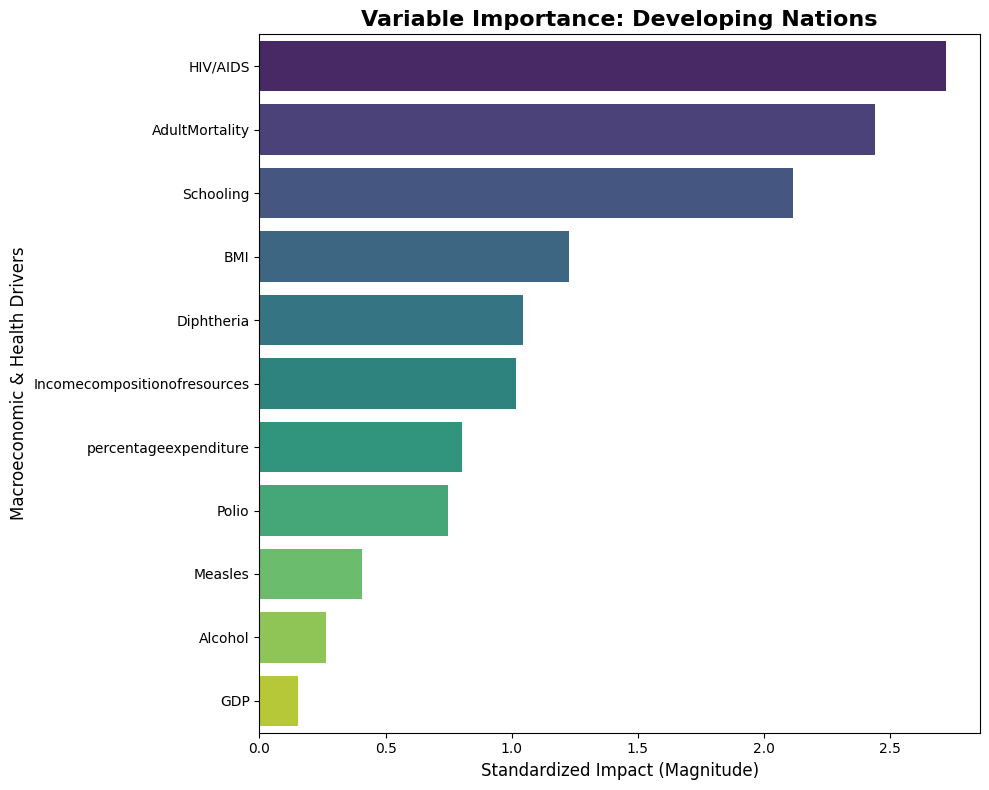

In [ ]:

#Save the rankings to a dataframe
developed_importance = get_variable_importance(best_developed_model)

#Set up the visual canvas
plt.figure(figsize=(10, 8))

#Create the horizontal bar chart
sns.barplot(
    data=developed_importance,
    x='Standardized_Impact',
    y='Variable',
    palette='viridis' # A professional, colorblind-friendly color scheme
)

#Add executive styling and labels
plt.title('Variable Importance: Developed Nations', fontsize=16, fontweight='bold')
plt.xlabel('Standardized Impact (Magnitude)', fontsize=12)
plt.ylabel('Macroeconomic & Health Drivers', fontsize=12)

#Clean layout and display
plt.tight_layout()
plt.show()

#Save the rankings to a dataframe
developing_importance = get_variable_importance(best_developing_model)

#Set up the visual canvas
plt.figure(figsize=(10, 8))

#Create the horizontal bar chart
sns.barplot(
    data=developing_importance,
    x='Standardized_Impact',
    y='Variable',
    palette='viridis' # A professional, colorblind-friendly color scheme
)

#Add executive styling and labels
plt.title('Variable Importance: Developing Nations', fontsize=16, fontweight='bold')
plt.xlabel('Standardized Impact (Magnitude)', fontsize=12)
plt.ylabel('Macroeconomic & Health Drivers', fontsize=12)

#Clean layout and display
plt.tight_layout()
plt.show()